# Global EDA

Dataset-wide electricity and metadata exploration for anomaly-detection preparation.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from IPython.display import display

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams.update({'figure.dpi': 100, 'axes.titlesize': 13, 'axes.labelsize': 11})

DATA_DIR  = Path('../../../data/building-data-genome-project-2/data')
ELEC_PATH = DATA_DIR / 'meters/cleaned/electricity_cleaned.csv'
META_PATH = DATA_DIR / 'metadata/metadata.csv'

## 1. Dataset Structure

In [2]:
elec = pd.read_csv(ELEC_PATH, parse_dates=['timestamp'])
elec.sort_values('timestamp', inplace=True)
elec.reset_index(drop=True, inplace=True)

building_cols = [c for c in elec.columns if c != 'timestamp']

print(f'Shape              : {elec.shape}')
print(f'Timestamps         : {elec.shape[0]:,}')
print(f'Building columns   : {len(building_cols):,}')

Shape              : (17544, 1579)
Timestamps         : 17,544
Building columns   : 1,578


In [3]:
display(elec[['timestamp'] + building_cols[:6]].head())

,timestamp,Panther_parking_Lorriane,Panther_lodging_Cora,Panther_office_Hannah,Panther_lodging_Hattie,Panther_education_Teofila,Panther_education_Jerome
0,2016-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN
1,2016-01-01 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN
2,2016-01-01 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN
3,2016-01-01 03:00:00,NaN,NaN,NaN,NaN,NaN,NaN
4,2016-01-01 04:00:00,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
dtype_counts = elec[building_cols].dtypes.value_counts().rename_axis('dtype').reset_index(name='count')
print('Electricity column dtypes:')
display(dtype_counts)

Electricity column dtypes:


,dtype,count
0,float64,1578


## 2. Timestamp Analysis

In [5]:
ts = elec['timestamp']
t_min, t_max = ts.min(), ts.max()
duration_days = (t_max - t_min).total_seconds() / 86400
diffs = ts.diff().dropna()
freq_mode = diffs.mode()[0]
expected_hourly = pd.Timedelta('1h')
non_hourly = (diffs != expected_hourly).sum()
gaps = diffs[diffs > expected_hourly]
n_duplicates = ts.duplicated().sum()

print(f'Earliest timestamp : {t_min}')
print(f'Latest timestamp   : {t_max}')
print(f'Duration           : {duration_days:.1f} days')
print(f'Most common freq   : {freq_mode}')
print(f'Is hourly (mode)   : {freq_mode == expected_hourly}')
print(f'Non-hourly steps   : {non_hourly:,}')
print(f'Gaps > 1 h         : {len(gaps):,}')
print(f'Duplicate timestamps: {n_duplicates:,}')

if len(gaps) > 0:
    print('\nLargest gaps:')
    gap_df = pd.DataFrame({'gap_start': ts[gaps.index - 1].values,
                           'gap_hours': (gaps / pd.Timedelta('1h')).values})
    display(gap_df.nlargest(10, 'gap_hours').reset_index(drop=True))

Earliest timestamp : 2016-01-01 00:00:00
Latest timestamp   : 2017-12-31 23:00:00
Duration           : 731.0 days
Most common freq   : 0 days 01:00:00
Is hourly (mode)   : True
Non-hourly steps   : 0
Gaps > 1 h         : 0
Duplicate timestamps: 0


## 3. Overall Missing Data

In [6]:
n_ts   = len(elec)
n_bld  = len(building_cols)
total_possible = n_ts * n_bld
total_missing  = elec[building_cols].isna().sum().sum()
overall_rate   = total_missing / total_possible

print(f'Total possible readings : {total_possible:,}')
print(f'Total missing readings  : {total_missing:,}')
print(f'Overall missing rate    : {overall_rate:.2%}')

Total possible readings : 27,684,432
Total missing readings  : 2,471,853
Overall missing rate    : 8.93%


In [7]:
elec_tmp = elec.set_index('timestamp')
missing_ts = elec_tmp[building_cols].isna().mean(axis=1)  # fraction of buildings missing per timestamp
missing_monthly = missing_ts.resample('ME').mean().rename('missing_rate')
missing_monthly.index = missing_monthly.index.to_period('M').astype(str)

ym_df = missing_monthly.reset_index()
ym_df.columns = ['year_month', 'missing_rate']
ym_df['year']  = ym_df['year_month'].str[:4]
ym_df['month'] = ym_df['year_month'].str[5:7]

print('Missing rate by year-month (fraction of building readings missing):')
display(ym_df.pivot(index='year', columns='month', values='missing_rate').style.format('{:.2%}'))

Missing rate by year-month (fraction of building readings missing):


month,01,02,03,04,05,06,07,08,09,10,11,12
year,,,,,,,,,,,,
2016,12.93%,17.41%,19.12%,12.57%,10.55%,6.55%,8.39%,7.45%,6.21%,8.08%,6.71%,8.38%
2017,7.12%,6.74%,7.44%,6.87%,8.48%,9.47%,7.40%,6.81%,6.66%,7.22%,7.82%,7.96%


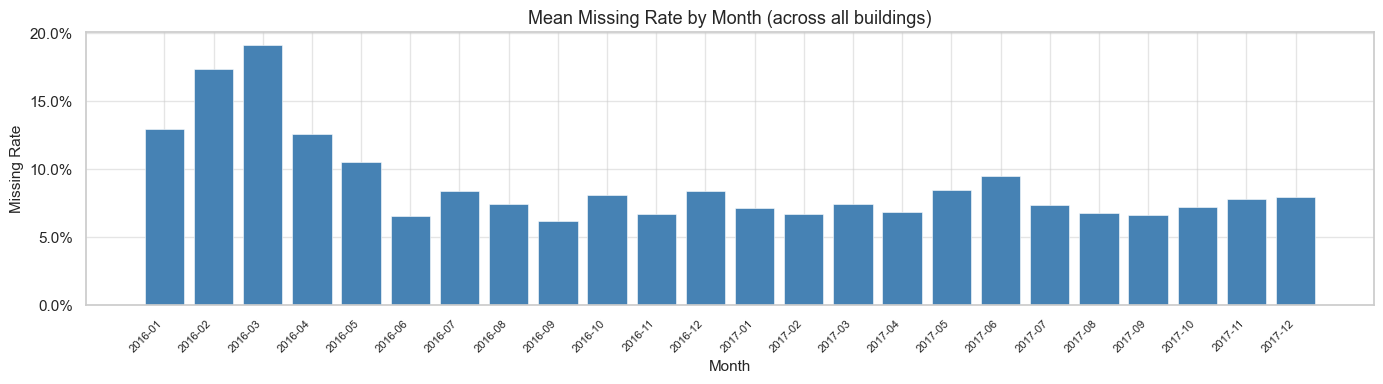

In [8]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(len(ym_df)), ym_df['missing_rate'], color='steelblue', edgecolor='white', linewidth=0.4)
ax.set_xticks(range(len(ym_df)))
ax.set_xticklabels(ym_df['year_month'], rotation=45, ha='right', fontsize=8)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_title('Mean Missing Rate by Month (across all buildings)')
ax.set_xlabel('Month')
ax.set_ylabel('Missing Rate')
plt.tight_layout()
plt.show()

## 4. Overall Consumption Statistics

In [9]:
# Stack column-by-column to avoid loading all values at once
chunk_stats = []
for col in building_cols:
    s = elec[col].dropna().values
    if len(s):
        chunk_stats.append(s)

all_vals = np.concatenate(chunk_stats)

pcts = np.percentile(all_vals, [1, 5, 25, 50, 75, 95, 99])
stats_dict = {
    'count' : len(all_vals),
    'mean'  : float(all_vals.mean()),
    'median': float(np.median(all_vals)),
    'std'   : float(all_vals.std()),
    'min'   : float(all_vals.min()),
    'p1'    : pcts[0],
    'p5'    : pcts[1],
    'p25'   : pcts[2],
    'p75'   : pcts[4],
    'p95'   : pcts[5],
    'p99'   : pcts[6],
    'max'   : float(all_vals.max()),
}
display(pd.DataFrame.from_dict(stats_dict, orient='index', columns=['value']).rename_axis('statistic'))
del chunk_stats

,value
statistic,
count,2.521258e+07
mean,1.449146e+02
median,5.957000e+01
std,2.688494e+02
min,1.000000e-04
p1,4.000000e-04
p5,1.440000e+00
p25,1.937500e+01
p75,1.568667e+02


## 5. Negative Values

In [10]:
neg_counts = (elec[building_cols] < 0).sum()
n_neg_total = neg_counts.sum()
n_valid = elec[building_cols].count().sum()
print(f'Total negative readings : {n_neg_total:,}')
print(f'Negative rate           : {n_neg_total / n_valid:.4%}')
print(f'Buildings with negatives: {(neg_counts > 0).sum():,}')

top_neg = neg_counts[neg_counts > 0].sort_values(ascending=False).head(20)
if len(top_neg):
    print('\nTop buildings by negative count:')
    display(top_neg.rename('negative_count').to_frame())

Total negative readings : 0
Negative rate           : 0.0000%
Buildings with negatives: 0


## 6. Zero Values

In [11]:
zero_counts = (elec[building_cols] == 0).sum()
n_zero_total = zero_counts.sum()
print(f'Total zero readings : {n_zero_total:,}')
print(f'Zero rate           : {n_zero_total / n_valid:.4%}')

Total zero readings : 0
Zero rate           : 0.0000%


## 7. Extreme Values

In [12]:
p99   = np.percentile(all_vals, 99)
p999  = np.percentile(all_vals, 99.9)
print(f'Global p99   threshold : {p99:.3f}')
print(f'Global p99.9 threshold : {p999:.3f}')

# Top 20 readings
records = []
for col in building_cols:
    col_max = elec[col].max()
    if pd.notna(col_max):
        records.append((col, col_max))

top20_bld = sorted(records, key=lambda x: x[1], reverse=True)[:20]
top20_rows = []
for bld, _ in top20_bld:
    idx = elec[bld].idxmax()
    top20_rows.append({'building_id': bld, 'timestamp': elec.loc[idx, 'timestamp'], 'value': elec.loc[idx, bld]})

display(pd.DataFrame(top20_rows).sort_values('value', ascending=False).reset_index(drop=True))

Global p99   threshold : 1244.320
Global p99.9 threshold : 2626.808


,building_id,timestamp,value
0,Bull_education_Dottie,2017-09-06 15:00:00,221228.0000
1,Bull_education_Delia,2017-11-27 12:00:00,55077.0000
2,Hog_office_Nia,2016-03-30 09:00:00,44336.4610
3,Bull_education_Jeffery,2016-10-17 07:00:00,30268.0000
4,Swan_unknown_Rocco,2017-03-15 16:00:00,18845.7369
5,Swan_unknown_Jerold,2017-01-24 08:00:00,14030.6778
6,Bull_lodging_Travis,2017-10-03 01:00:00,12576.0000
7,Bull_assembly_Nick,2016-02-26 08:00:00,11624.0000
8,Bull_education_Barry,2016-12-10 15:00:00,11019.0000
9,Bull_assembly_Lance,2016-03-30 01:00:00,10725.0000


## 8. Temporal Consumption Patterns

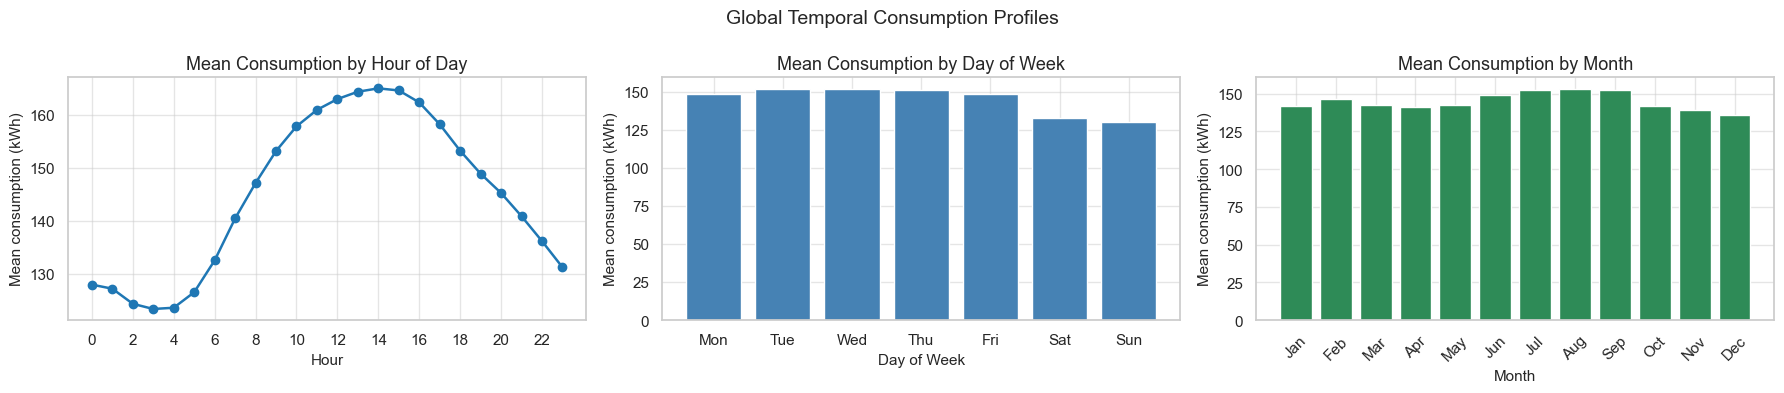

In [13]:
# Row-mean across buildings (memory-friendly)
elec_idx = elec.set_index('timestamp')
row_mean = elec_idx[building_cols].mean(axis=1)

hourly_profile  = row_mean.groupby(row_mean.index.hour).mean()
dow_profile     = row_mean.groupby(row_mean.index.dayofweek).mean()
monthly_profile = row_mean.groupby(row_mean.index.month).mean()

day_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(hourly_profile.index, hourly_profile.values, marker='o', linewidth=1.8)
axes[0].set_title('Mean Consumption by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Mean consumption (kWh)')
axes[0].set_xticks(range(0, 24, 2))

axes[1].bar(dow_profile.index, dow_profile.values, color='steelblue', edgecolor='white')
axes[1].set_title('Mean Consumption by Day of Week')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Mean consumption (kWh)')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(day_labels)

axes[2].bar(monthly_profile.index, monthly_profile.values, color='seagreen', edgecolor='white')
axes[2].set_title('Mean Consumption by Month')
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Mean consumption (kWh)')
axes[2].set_xticks(range(1, 13))
axes[2].set_xticklabels(month_labels, rotation=45)

plt.suptitle('Global Temporal Consumption Profiles', fontsize=14)
plt.tight_layout()
plt.show()

## 9. Metadata Overview

In [14]:
meta = pd.read_csv(META_PATH)
print(f'Metadata shape  : {meta.shape}')
print(f'Metadata columns: {list(meta.columns)}')

Metadata shape  : (1636, 32)
Metadata columns: ['building_id', 'site_id', 'building_id_kaggle', 'site_id_kaggle', 'primaryspaceusage', 'sub_primaryspaceusage', 'sqm', 'sqft', 'lat', 'lng', 'timezone', 'electricity', 'hotwater', 'chilledwater', 'steam', 'water', 'irrigation', 'solar', 'gas', 'industry', 'subindustry', 'heatingtype', 'yearbuilt', 'date_opened', 'numberoffloors', 'occupants', 'energystarscore', 'eui', 'site_eui', 'source_eui', 'leed_level', 'rating']


In [15]:
elec_bld_set  = set(building_cols)
meta_bld_set  = set(meta['building_id'].dropna())
matched   = elec_bld_set & meta_bld_set
unmatched_elec = elec_bld_set - meta_bld_set
unmatched_meta = meta_bld_set - elec_bld_set

print(f'Buildings in electricity data : {len(elec_bld_set):,}')
print(f'Buildings in metadata         : {len(meta_bld_set):,}')
print(f'Matched (both datasets)       : {len(matched):,}')
print(f'In electricity, not metadata  : {len(unmatched_elec):,}')
print(f'In metadata, not electricity  : {len(unmatched_meta):,}')

Buildings in electricity data : 1,578
Buildings in metadata         : 1,636
Matched (both datasets)       : 1,578
In electricity, not metadata  : 0
In metadata, not electricity  : 58


In [16]:
site_counts  = meta['site_id'].value_counts().rename_axis('site_id').reset_index(name='building_count')
usage_counts = meta['primaryspaceusage'].value_counts().rename_axis('usage').reset_index(name='building_count')

print('Building count by site_id:')
display(site_counts)
print('\nBuilding count by primaryspaceusage:')
display(usage_counts)

Building count by site_id:


,site_id,building_count
0,Rat,305
1,Hog,163
2,Lamb,147
3,Fox,137
4,Panther,136
5,Bull,124
6,Cockatoo,124
7,Eagle,106
8,Bear,92
9,Gator,74



Building count by primaryspaceusage:


,usage,building_count
0,Education,617
1,Office,307
2,Entertainment/public assembly,204
3,Lodging/residential,168
4,Public services,166
5,Other,29
6,Healthcare,29
7,Parking,24
8,Warehouse/storage,15
9,Manufacturing/industrial,13


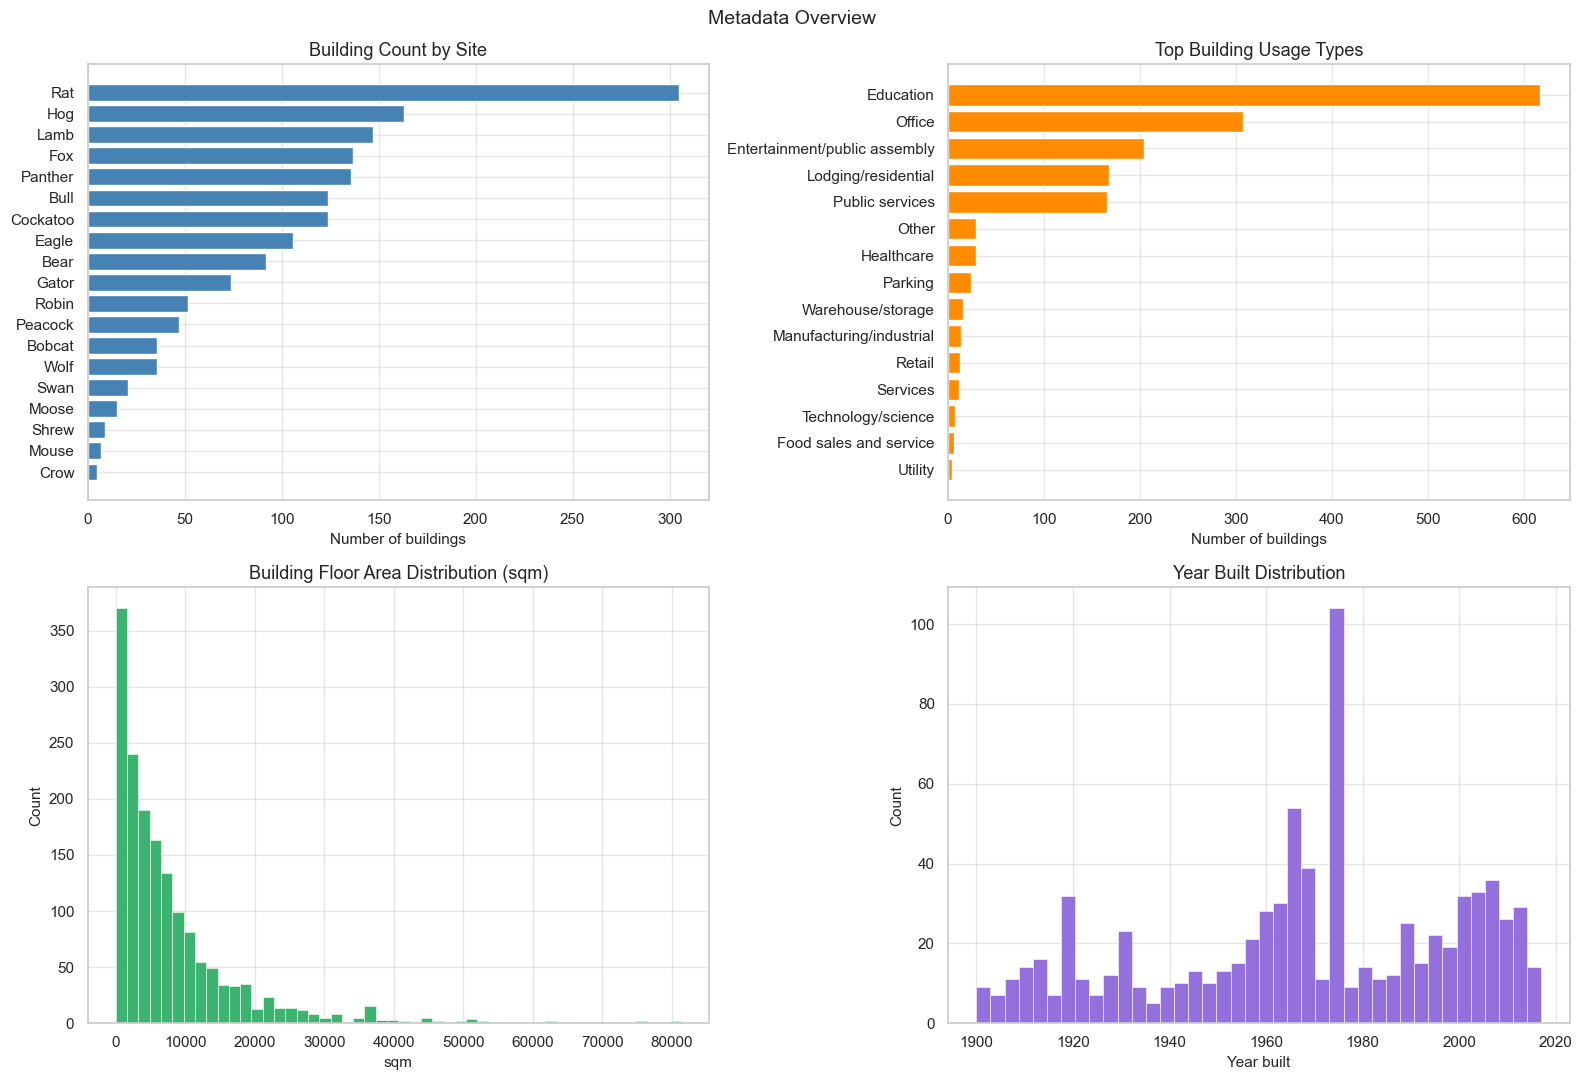

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# Site building count
axes[0, 0].barh(site_counts['site_id'], site_counts['building_count'], color='steelblue')
axes[0, 0].set_title('Building Count by Site')
axes[0, 0].set_xlabel('Number of buildings')
axes[0, 0].invert_yaxis()

# Top usage types
top_usage = usage_counts.head(15)
axes[0, 1].barh(top_usage['usage'], top_usage['building_count'], color='darkorange')
axes[0, 1].set_title('Top Building Usage Types')
axes[0, 1].set_xlabel('Number of buildings')
axes[0, 1].invert_yaxis()

# sqm distribution
sqm_vals = meta['sqm'].dropna()
axes[1, 0].hist(sqm_vals, bins=50, edgecolor='white', linewidth=0.4, color='mediumseagreen')
axes[1, 0].set_title('Building Floor Area Distribution (sqm)')
axes[1, 0].set_xlabel('sqm')
axes[1, 0].set_ylabel('Count')

# yearbuilt distribution
yb_vals = meta['yearbuilt'].dropna()
axes[1, 1].hist(yb_vals, bins=40, edgecolor='white', linewidth=0.4, color='mediumpurple')
axes[1, 1].set_title('Year Built Distribution')
axes[1, 1].set_xlabel('Year built')
axes[1, 1].set_ylabel('Count')

plt.suptitle('Metadata Overview', fontsize=14)
plt.tight_layout()
plt.show()

## Summary Observations

- **Dataset coverage**: 1,578 buildings x 17,544 hourly readings, covering 2016-01-01 through 2017-12-31. The timestamp series is regular hourly data with no gaps and no duplicate timestamps.
- **Missingness is material but not dominant**: 2,471,853 readings are missing, an overall missing rate of 8.93%. Missingness should be handled before modeling, but the dataset remains broadly usable.
- **Lower-bound quality is clean**: there are no negative readings and no exact zero readings. Near-zero repeated values still need separate treatment in anomaly detection because they are non-zero and will not be caught by exact-zero rules.
- **Consumption is highly right-skewed**: mean consumption is 144.9 kWh while the median is 59.6 kWh. The p99 is 1,244 kWh, p99.9 is 2,627 kWh, and the max is 221,228 kWh.
- **Extreme readings are obvious anomaly candidates**: `Bull_education_Dottie` reaches 221,228 kWh on 2017-09-06 15:00, more than 4x the next highest maximum. Bull and Swan buildings dominate the top extremes.
- **Temporal structure is usable**: global consumption peaks around hour 14 and troughs around hour 3. Weekdays are higher than weekends, and August is the peak month while December is the trough.
- **Metadata coverage is complete for electricity buildings**: all 1,578 electricity columns match metadata records; 58 metadata-only buildings have no electricity data.
